---
# Pre-TARE Adoption KPIs: Spark Gap, Thermal COP, Break-Even COP
---

**Author:** Jordan M. Joseph, PhD — Carnegie Mellon University

Computes adoption economics metrics that can be calculated directly from EUSS
data and EIA fuel prices, without requiring a TARE model run.

**Workflow:** Load EUSS data → spark gap → thermal COP & AFUE → break-even COP → maps

**Batch Mode:** Set `input_measure_package` before calling via `%run -i` to skip prompts.

See `README_adoption_kpis.md` for methodology notes and design decisions.

---
## Step 0: Imports and Configuration
---

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from config import PROJECT_ROOT
from cmu_tare_model.constants import ALLOWED_HOUSING_TYPES, VALID_MENU_MPS, VERBOSE

from cmu_tare_model.adoption_kpis.kpi_functions import (
    mp_to_upgrade,
    load_euss_baseline,
    load_euss_upgrade,
    calculate_price_ratios,
    compute_thermal_cop,          # renamed from compute_thermal_cop_by_state
    compute_breakeven_cop,
    compute_spark_gap_metrics,
    iecc_to_cz_group,             # new — climate zone mapping
    COP_BENCHMARK_RANGES,         # new — validation benchmark ranges
    FUEL_PRICES_PATH,
    SHAPEFILE_PATH,
    HEATING_LOAD_COL,
    CLIMATE_ZONE_COL,             # new — column name constant
)
from cmu_tare_model.adoption_kpis.visualize_geospatial_data import (
    prepare_state_geodataframe,
    create_choropleth_map,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)

print("✓ Imports loaded")
print(f"Project root: {PROJECT_ROOT}")

Project root directory: c:\users\jorda\desktop\projects\cmu-tare-model
✓ Imports loaded
Project root: c:\users\jorda\desktop\projects\cmu-tare-model


---
## Step 0b: Measure Package Selection
---

In [2]:
SELECTABLE_MPS = [mp for mp in VALID_MENU_MPS if mp != 0]

try:
    _ = input_measure_package
    batch_mode = True
    selected_mps = [int(input_measure_package)]
    print(f"BATCH MODE: Running for MP{selected_mps[0]}")
except NameError:
    batch_mode = False
    print(f"Available measure packages: {SELECTABLE_MPS}")
    mp_input = input("Enter MP numbers (comma-separated, or 'all'): ").strip()
    if mp_input.lower() == 'all':
        selected_mps = SELECTABLE_MPS
    else:
        selected_mps = [int(x.strip()) for x in mp_input.split(',') if x.strip().isdigit()]
        selected_mps = [mp for mp in selected_mps if mp in SELECTABLE_MPS]
    if not selected_mps:
        selected_mps = [4]
        print("No valid MPs selected. Defaulting to MP4.")

print(f"\nSelected measure packages: {selected_mps}")

Available measure packages: [3, 4, 8]

Selected measure packages: [3, 4]


---
## Step 1: Load EUSS Data
---

In [3]:
print("=" * 80)
print("STEP 1: LOAD EUSS DATA")
print("=" * 80)

df_baseline = load_euss_baseline()
print(f"  Baseline: {len(df_baseline):,} occupied SF homes")

upgrade_data = {}
for mp in selected_mps:
    upgrade_name = mp_to_upgrade(mp)
    print(f"\nLoading MP{mp} ({upgrade_name})...")
    upgrade_data[mp] = load_euss_upgrade(upgrade_name)
    print(f"  MP{mp}: {len(upgrade_data[mp]):,} applicable homes")

print(f"\n✓ STEP 1 COMPLETE")

STEP 1: LOAD EUSS DATA
Loading baseline from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\baseline_metadata_and_annual_results.csv
  After occupancy filter: 482,597 / 548,916
  After housing type filter (['Single-Family Attached', 'Single-Family Detached']): 331,531
  Baseline: 331,531 occupied SF homes

Loading MP3 (upgrade03)...
Loading upgrade03 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade03_metadata_and_annual_results.csv
  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP3: 331,526 applicable homes

Loading MP4 (upgrade04)...
Loading upgrade04 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade04_metadata_and_annual_results.csv
  After occupancy filter: 482,597 / 548,916

---
## Step 2: Fuel Price Ratios (Spark Gap)
---

In [4]:
print("===== STEP 2: FUEL PRICE RATIOS (CSV, nominal) =====")

# --- 2022 single-year ---
df_prices_2022 = calculate_price_ratios(FUEL_PRICES_PATH, year=2022)
print(f"✓ 2022 prices loaded for {len(df_prices_2022)} states")
print(f"  Spark Gap — Mean: {df_prices_2022['spark_gap'].mean():.2f}, "
      f"Range: {df_prices_2022['spark_gap'].min():.2f}–{df_prices_2022['spark_gap'].max():.2f}")

# --- 2024 single-year ---
df_prices_csv = calculate_price_ratios(FUEL_PRICES_PATH, year=2024)
print(f"\n✓ 2024 prices loaded for {len(df_prices_csv)} states")
print(f"  Spark Gap — Mean: {df_prices_csv['spark_gap'].mean():.2f}, "
      f"Range: {df_prices_csv['spark_gap'].min():.2f}–{df_prices_csv['spark_gap'].max():.2f}")

# --- 5-year average (2020–2024) ---
df_prices_5yr = calculate_price_ratios(FUEL_PRICES_PATH, year=list(range(2020, 2025)))
print(f"\n✓ 5-year avg (2020–2024) loaded for {len(df_prices_5yr)} states")
print(f"  Spark Gap — Mean: {df_prices_5yr['spark_gap'].mean():.2f}, "
      f"Range: {df_prices_5yr['spark_gap'].min():.2f}–{df_prices_5yr['spark_gap'].max():.2f}")

# --- 10-year average (2015–2024) ---
df_prices_10yr = calculate_price_ratios(FUEL_PRICES_PATH, year=list(range(2015, 2025)))
print(f"\n✓ 10-year avg (2015–2024) loaded for {len(df_prices_10yr)} states")
print(f"  Spark Gap — Mean: {df_prices_10yr['spark_gap'].mean():.2f}, "
      f"Range: {df_prices_10yr['spark_gap'].min():.2f}–{df_prices_10yr['spark_gap'].max():.2f}")

print(f"\n✓ STEP 2 COMPLETE")

===== STEP 2: FUEL PRICE RATIOS (CSV, nominal) =====
✓ 2022 prices loaded for 51 states
  Spark Gap — Mean: 3.15, Range: 1.61–6.34

✓ 2024 prices loaded for 51 states
  Spark Gap — Mean: 3.55, Range: 1.70–6.44

✓ 5-year avg (2020–2024) loaded for 51 states
  Spark Gap — Mean: 3.41, Range: 1.67–6.32

✓ 10-year avg (2015–2024) loaded for 51 states
  Spark Gap — Mean: 3.55, Range: 1.67–6.27

✓ STEP 2 COMPLETE


In [5]:
# Build summary table: 2024 prices + spark gaps for 2022, 2024, 5yr, 10yr
df_summary = df_prices_csv[['state', 'state_name', 'elec_price_mmbtu', 'gas_price_mmbtu']].copy()
df_summary = df_summary.rename(columns={
    'elec_price_mmbtu': 'elec_$/mmbtu_2024',
    'gas_price_mmbtu': 'gas_$/mmbtu_2024',
})

df_summary = df_summary.merge(
    df_prices_2022[['state', 'spark_gap']].rename(columns={'spark_gap': 'spark_gap_2022'}),
    on='state', how='inner',
)
df_summary = df_summary.merge(
    df_prices_csv[['state', 'spark_gap']].rename(columns={'spark_gap': 'spark_gap_2024'}),
    on='state', how='inner',
)
df_summary = df_summary.merge(
    df_prices_5yr[['state', 'spark_gap']].rename(columns={'spark_gap': 'spark_gap_5yr_avg'}),
    on='state', how='inner',
)
df_summary = df_summary.merge(
    df_prices_10yr[['state', 'spark_gap']].rename(columns={'spark_gap': 'spark_gap_10yr_avg'}),
    on='state', how='inner',
)

# Sort by 2024 spark gap for display
df_summary = df_summary.sort_values('spark_gap_2024', ascending=False).reset_index(drop=True)

display_cols = [
    'state', 'state_name',
    'elec_$/mmbtu_2024', 'gas_$/mmbtu_2024',
    'spark_gap_2022', 'spark_gap_2024', 'spark_gap_5yr_avg', 'spark_gap_10yr_avg',
]

print("=" * 100)
print("SPARK GAP SUMMARY: TOP 5 & BOTTOM 5 STATES")
print("=" * 100)
print(f"\n{'Elec & Gas prices shown as 2024 nominal $/MMBTU'}")
print(f"{'Spark Gap = Electricity Price / Natural Gas Price'}\n")

print("--- Top 5 (highest spark gap, most favorable for gas heating) ---")
print(df_summary[display_cols].head(5).to_string(index=False))

print("\n--- Bottom 5 (lowest spark gap, most favorable for heat pumps) ---")
print(df_summary[display_cols].tail(5).to_string(index=False))

print(f"\n--- National Summary ---")
for label, col in [('2022', 'spark_gap_2022'), ('2024', 'spark_gap_2024'),
                    ('5yr avg', 'spark_gap_5yr_avg'), ('10yr avg', 'spark_gap_10yr_avg')]:
    vals = df_summary[col]
    print(f"  {label:>8}: Mean={vals.mean():.2f}, Median={vals.median():.2f}, "
          f"Range=[{vals.min():.2f}, {vals.max():.2f}]")

SPARK GAP SUMMARY: TOP 5 & BOTTOM 5 STATES

Elec & Gas prices shown as 2024 nominal $/MMBTU
Spark Gap = Electricity Price / Natural Gas Price

--- Top 5 (highest spark gap, most favorable for gas heating) ---
state  state_name  elec_$/mmbtu_2024  gas_$/mmbtu_2024  spark_gap_2022  spark_gap_2024  spark_gap_5yr_avg  spark_gap_10yr_avg
   AK      Alaska              72.74             11.30            6.34            6.44               6.32                6.27
   MI    Michigan              56.56             10.37            4.80            5.46               5.36                5.45
   CT Connecticut              84.26             16.21            4.08            5.20               4.59                4.63
   WI   Wisconsin              50.35              9.77            4.19            5.15               4.81                5.02
   CA  California              93.69             18.44            3.90            5.08               4.34                4.41

--- Bottom 5 (lowest spark gap, mo

---
## Step 3: Thermal COP and Baseline AFUE
---

In [6]:
cop_results = {}

for mp in selected_mps:
    print(f"\n{'=' * 80}")
    print(f"STEP 3: THERMAL COP & BASELINE AFUE (MP{mp}, Natural Gas homes)")
    print(f"{'=' * 80}")

    cop_results[mp] = compute_thermal_cop(
        df_baseline, upgrade_data[mp],
        group_cols=['state'],
        fuel_filter='Natural Gas',
        verbose=True,
    )

    df_cop_mp = cop_results[mp]
    print(f"\n--- Top 5 by COP (MP{mp}) ---")
    print(df_cop_mp.sort_values('thermal_cop', ascending=False).head(5)[
        ['state', 'thermal_cop', 'baseline_afue', 'fans_pumps_pct', 'home_count']
    ].to_string(index=False))

    print(f"\n--- Bottom 5 by COP (MP{mp}) ---")
    print(df_cop_mp.sort_values('thermal_cop', ascending=True).head(5)[
        ['state', 'thermal_cop', 'baseline_afue', 'fans_pumps_pct', 'home_count']
    ].to_string(index=False))

    # Validation: heating load consistency
    common_ids = df_baseline.index.intersection(upgrade_data[mp].index)
    Q_baseline = df_baseline.loc[common_ids, HEATING_LOAD_COL].fillna(0)
    Q_upgrade = upgrade_data[mp].loc[common_ids, HEATING_LOAD_COL].fillna(0)
    mask = Q_baseline > 0
    pct_diff = ((Q_upgrade[mask] - Q_baseline[mask]) / Q_baseline[mask]).median()
    print(f"\nHeating load consistency: {pct_diff:.1%} median difference (expect ±5–10%)")

primary_mp = selected_mps[0]
df_cop = cop_results[primary_mp]
df_upgrade_primary = upgrade_data[primary_mp]
print(f"\n✓ STEP 3 COMPLETE — Primary MP: {primary_mp}")


STEP 3: THERMAL COP & BASELINE AFUE (MP3, Natural Gas homes)
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 homes (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas, by state) ---
Groups: 49
Mean:   2.21
Median: 2.20
Range:  1.53 - 3.05
✓ All groups within expected COP range (1.5–5.0)

--- Baseline AFUE Summary (Natural Gas) ---
Mean:   0.80
Median: 0.80
Range:  0.75 - 0.82

--- Fan/Pump Energy as % of Total HP Electricity ---
Mean:   3.8%
Range:  1.7% - 5.8%

--- Top 5 by COP (MP3) ---
state  thermal_cop  baseline_afue  fans_pumps_pct  home_count
   CA     3.054755       0.801801        4.001501       24571
   FL     2.893052       0.794453        5.682569        1084
   LA     2.758595       0.799742        5.761571        2139
   TX     2.748806       0.804379        5.035227       12362
   DC     2.715392       0.752035        4.055966         338

--- Bottom 5 by COP (MP3) ---
s

---
## Task B: COP Direction Check (Zero-Baseline Filter Validation)
---

Validates that the zero-baseline filter (excluding homes with no prior
heating system) lowers COP as expected. Compares fixed (default) vs
unfixed (`require_baseline_heating=False`) results per state.

In [7]:
print("=" * 80)
print("TASK B: COP DIRECTION CHECK (zero-baseline filter validation)")
print("=" * 80)

for mp in selected_mps:
    print(f"\n--- MP{mp} ---")

    # Unfixed: include homes with zero baseline heating (old behavior)
    cop_unfixed = compute_thermal_cop(
        df_baseline, upgrade_data[mp],
        group_cols=['state'],
        fuel_filter='Natural Gas',
        require_baseline_heating=False,
        verbose=False,
    )

    # Fixed: cop_results[mp] already computed with require_baseline_heating=True (default)
    cop_fixed = cop_results[mp]

    # Merge for comparison
    df_compare = cop_unfixed[['state', 'thermal_cop']].rename(
        columns={'thermal_cop': 'cop_unfixed'}
    ).merge(
        cop_fixed[['state', 'thermal_cop']].rename(
            columns={'thermal_cop': 'cop_fixed'}
        ),
        on='state', how='outer',
    )
    df_compare['delta'] = df_compare['cop_fixed'] - df_compare['cop_unfixed']
    df_compare['direction_ok'] = df_compare['cop_fixed'] <= df_compare['cop_unfixed']

    print(f"\n{'State':<6} {'COP_unfixed':>12} {'COP_fixed':>10} {'Delta':>8} {'Dir OK?':>8}")
    print("-" * 48)
    for _, r in df_compare.sort_values('state').iterrows():
        print(f"{r['state']:<6} {r['cop_unfixed']:>12.3f} {r['cop_fixed']:>10.3f} "
              f"{r['delta']:>+8.3f} {'✓' if r['direction_ok'] else '✗':>8}")

    n_pass = df_compare['direction_ok'].sum()
    n_total = len(df_compare)
    n_fail = n_total - n_pass
    print(f"\nSummary: {n_pass}/{n_total} states pass direction check")
    if n_fail > 0:
        fails = df_compare[~df_compare['direction_ok']]
        print(f"⚠ {n_fail} state(s) where fixed COP > unfixed (investigate):")
        for _, r in fails.iterrows():
            print(f"    {r['state']}: unfixed={r['cop_unfixed']:.3f}, "
                  f"fixed={r['cop_fixed']:.3f}, delta={r['delta']:+.3f}")
    else:
        print("✓ All states: fixed COP ≤ unfixed COP (filter lowered COP as expected)")

print(f"\n✓ TASK B COMPLETE")

TASK B: COP DIRECTION CHECK (zero-baseline filter validation)

--- MP3 ---

State   COP_unfixed  COP_fixed    Delta  Dir OK?
------------------------------------------------
AL            2.608      2.608   +0.000        ✓
AR            2.499      2.499   +0.000        ✓
AZ            2.587      2.588   +0.001        ✗
CA            3.054      3.055   +0.001        ✗
CO            1.952      1.952   +0.000        ✓
CT            2.086      2.086   +0.000        ✓
DC            2.715      2.715   +0.000        ✓
DE            2.315      2.315   +0.000        ✓
FL            2.893      2.893   +0.000        ✗
GA            2.599      2.599   +0.000        ✓
IA            1.763      1.763   +0.000        ✓
ID            2.155      2.155   +0.000        ✓
IL            1.946      1.946   +0.000        ✓
IN            1.972      1.972   +0.000        ✓
KS            2.201      2.201   +0.000        ✓
KY            2.290      2.290   +0.000        ✓
LA            2.759      2.759   +0.000   

---
## Task C: Climate Zone Benchmark Validation
---

Aggregates thermal COP by IECC climate zone group and validates against
literature-derived benchmark ranges (`COP_BENCHMARK_RANGES`). Also
produces a state × climate zone cross-tab with a PA spot check.

In [8]:
print("=" * 80)
print("TASK C: CLIMATE ZONE BENCHMARK VALIDATION")
print("=" * 80)

for mp in selected_mps:
    mp_key = f'mp{mp}'
    print(f"\n{'─' * 60}")
    print(f"MP{mp} — Climate Zone Group Aggregation")
    print(f"{'─' * 60}")

    # --- C1: COP by climate zone group ---
    df_cop_cz = compute_thermal_cop(
        df_baseline, upgrade_data[mp],
        group_cols=['cz_group'],
        fuel_filter='Natural Gas',
        verbose=True,
    )

    # --- C2: COP by state × climate zone group ---
    df_cop_state_cz = compute_thermal_cop(
        df_baseline, upgrade_data[mp],
        group_cols=['state', 'cz_group'],
        fuel_filter='Natural Gas',
        verbose=True,
    )

    # --- C3: Validate against COP_BENCHMARK_RANGES ---
    print(f"\n--- Benchmark Validation (MP{mp}) ---")
    print(f"{'CZ Group':<10} {'Label':<18} {'COP':>6} {'Expected':>14} {'Pass':>6}")
    print("-" * 58)
    n_checked = 0
    n_passed = 0
    for cz_grp, bench in COP_BENCHMARK_RANGES.items():
        row = df_cop_cz[df_cop_cz['cz_group'] == cz_grp]
        if len(row) == 0:
            print(f"{cz_grp:<10} {bench['label']:<18} {'N/A':>6} {'':<14} {'SKIP':>6}")
            continue
        cop_val = row['thermal_cop'].values[0]
        if mp_key in bench:
            lo, hi = bench[mp_key]
            in_range = lo <= cop_val <= hi
            n_checked += 1
            n_passed += int(in_range)
            range_str = f"[{lo:.1f}, {hi:.1f}]"
            print(f"{cz_grp:<10} {bench['label']:<18} {cop_val:>6.2f} {range_str:>14} "
                  f"{'✓' if in_range else '✗':>6}")
        else:
            print(f"{cz_grp:<10} {bench['label']:<18} {cop_val:>6.2f} {'no bench':>14} {'—':>6}")

    print(f"\nOverall: {n_passed}/{n_checked} climate zone groups within expected range")

    # --- C4: PA spot check ---
    pa_rows = df_cop_state_cz[df_cop_state_cz['state'] == 'PA']
    if len(pa_rows) > 0:
        print(f"\n--- PA Spot Check (MP{mp}) ---")
        # ASSUMPTION: PA is primarily CZ 4-5
        pa_ranges = {'mp3': (1.8, 2.4), 'mp4': (2.5, 3.4)}
        for _, pa_row in pa_rows.iterrows():
            cop_val = pa_row['thermal_cop']
            cz = pa_row['cz_group']
            if mp_key in pa_ranges:
                lo, hi = pa_ranges[mp_key]
                ok = lo <= cop_val <= hi
                print(f"  PA (CZ {cz}): COP = {cop_val:.2f}, "
                      f"expected [{lo:.1f}, {hi:.1f}] → {'✓ PASS' if ok else '✗ FAIL'}")
            else:
                print(f"  PA (CZ {cz}): COP = {cop_val:.2f} (no PA benchmark for {mp_key})")
    else:
        print("\n⚠ PA not found in state × CZ cross-tab")

print(f"\n✓ TASK C COMPLETE")

TASK C: CLIMATE ZONE BENCHMARK VALIDATION

────────────────────────────────────────────────────────────
MP3 — Climate Zone Group Aggregation
────────────────────────────────────────────────────────────
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 homes (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas, by cz_group) ---
Groups: 3
Mean:   2.15
Median: 2.05
Range:  1.67 - 2.74
✓ All groups within expected COP range (1.5–5.0)

--- Baseline AFUE Summary (Natural Gas) ---
Mean:   0.80
Median: 0.80
Range:  0.80 - 0.81

--- Fan/Pump Energy as % of Total HP Electricity ---
Mean:   3.4%
Range:  2.2% - 4.8%
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 homes (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas, by state × cz_group) ---
Groups: 72
Mean:   2.22
Median: 2.20
Range:  1.53 - 3.15


---
## Task D: Break-Even COP Cross-Validation (Jenkins et al.)
---

Rich cross-validation against Jenkins Heat Pump Map reference values.
For each reference state: compares thermal COP, spark gap, computed
break-even COP at 90% AFUE, and Jenkins reference. Determines whether
the heat pump beats break-even and whether the computed value matches
Jenkins within strict (±0.05) and relaxed (±0.50) tolerances.

**Known discrepancy sources:**
1. Gas heat content — Jenkins: 1020 BTU/cf; ours: 1038 BTU/cf (EIA average)
2. ~~Price year — Jenkins: earlier year; ours: 2024 EIA nominal~~

In [9]:
print("=" * 80)
print(f"TASK D: BREAK-EVEN COP CROSS-VALIDATION (Jenkins et al., MP{primary_mp})")
print("=" * 80)

# Jenkins Heat Pump Map break-even COP at 90% AFUE reference values
# Source: Jenkins et al.
# ASSUMPTION: Jenkins assumes 1020 BTU/cf gas heat content; we use 1038 BTU/cf
# (current EIA average). This ~1.8% difference propagates into spark gap and
# break-even COP. Our prices are now 2024 EIA nominal (same as Jenkins).
jenkins_ref = {
    'FL': 1.50, 'PA': 3.51, 'MN': 3.90,
    'AK': 5.69, 'CA': 4.49, 'MA': 3.60,
}

# Use state-level COP from cop_results and spark gap from current prices
df_prices_for_d = calculate_price_ratios(FUEL_PRICES_PATH, year=2024)
df_breakeven_for_d = compute_breakeven_cop(df_prices_for_d, afue_scenarios=[0.90])
df_spark_for_d = compute_spark_gap_metrics(
    df_prices_for_d, cop_results[primary_mp],
    df_breakeven=df_breakeven_for_d, verbose=False,
)

header = (f"{'State':<6} {'COP':>6} {'Spark':>6} {'BE_90':>6} "
          f"{'Jenkins':>8} {'Strict':>7} {'Relaxed':>8} {'HP>BE?':>7}")
print(f"\n{header}")
print("-" * len(header))

n_strict = 0
n_relaxed = 0
for st, ref_val in sorted(jenkins_ref.items()):
    row_cop = cop_results[primary_mp][cop_results[primary_mp]['state'] == st]
    row_spark = df_spark_for_d[df_spark_for_d['state'] == st]

    if len(row_cop) == 0 or len(row_spark) == 0:
        print(f"{st:<6} {'N/A':>6} {'N/A':>6} {'N/A':>6} {ref_val:>8.2f} "
              f"{'—':>7} {'—':>8} {'—':>7}")
        continue

    thermal_cop = row_cop['thermal_cop'].values[0]
    spark_gap = row_spark['spark_gap'].values[0]
    # ASSUMPTION: breakeven_cop_90 = spark_gap * 0.90
    breakeven_cop_90 = spark_gap * 0.90

    cop_exceeds = thermal_cop > breakeven_cop_90
    strict = abs(ref_val - breakeven_cop_90) <= 0.05
    relaxed = abs(ref_val - breakeven_cop_90) <= 0.50
    n_strict += int(strict)
    n_relaxed += int(relaxed)

    print(f"{st:<6} {thermal_cop:>6.2f} {spark_gap:>6.2f} {breakeven_cop_90:>6.2f} "
          f"{ref_val:>8.2f} {'✓' if strict else '✗':>7} "
          f"{'✓' if relaxed else '✗':>8} {'Yes' if cop_exceeds else 'No':>7}")

n_total = len(jenkins_ref)
print(f"\nStrict match (±0.05): {n_strict}/{n_total}")
print(f"Relaxed match (±0.50): {n_relaxed}/{n_total}")
print(f"\nNote: Remaining discrepancies arise from (1) gas heat content "
      f"(Jenkins: 1020, ours: 1038 BTU/cf)")

# Interpretation
print("\n--- Interpretation ---")
warm = ['FL']
cold = ['MN', 'AK']
for label, states in [('Warm', warm), ('Cold', cold)]:
    for st in states:
        row_cop = cop_results[primary_mp][cop_results[primary_mp]['state'] == st]
        row_spark = df_spark_for_d[df_spark_for_d['state'] == st]
        if len(row_cop) == 0 or len(row_spark) == 0:
            continue
        cop_val = row_cop['thermal_cop'].values[0]
        be_val = row_spark['spark_gap'].values[0] * 0.90
        exceeds = cop_val > be_val
        msg = "HP saves money on fuel" if exceeds else "HP does NOT beat furnace on fuel cost"
        print(f"  {st} ({label}): COP={cop_val:.2f}, BE_90={be_val:.2f} → {msg}")

print(f"\n✓ TASK D COMPLETE")

TASK D: BREAK-EVEN COP CROSS-VALIDATION (Jenkins et al., MP3)

State     COP  Spark  BE_90  Jenkins  Strict  Relaxed  HP>BE?
-------------------------------------------------------------
AK        N/A    N/A    N/A     5.69       —        —       —
CA       3.05   5.08   4.57     4.49       ✗        ✓      No
FL       2.89   1.70   1.53     1.50       ✓        ✓     Yes
MA       2.01   4.08   3.67     3.60       ✗        ✓      No
MN       1.59   4.41   3.97     3.90       ✗        ✓      No
PA       2.02   3.97   3.57     3.51       ✗        ✓      No

Strict match (±0.05): 1/6
Relaxed match (±0.50): 5/6

Note: Remaining discrepancies arise from (1) gas heat content (Jenkins: 1020, ours: 1038 BTU/cf)

--- Interpretation ---
  FL (Warm): COP=2.89, BE_90=1.53 → HP saves money on fuel
  MN (Cold): COP=1.59, BE_90=3.97 → HP does NOT beat furnace on fuel cost

✓ TASK D COMPLETE


---
## Step 4: Break-Even COP and Merged Metrics
---

In [10]:
print("=" * 80)
print("STEP 4: BREAK-EVEN COP & MERGED METRICS")
print("=" * 80)

# --- 4a: Compute break-even COP for multiple AFUE scenarios ---
# ASSUMPTION: 2024 EIA state-level residential prices.
afue_scenarios = [0.80, 0.90, 0.95, 1.00]
df_breakeven = compute_breakeven_cop(df_prices_csv, afue_scenarios=afue_scenarios)
print(f"✓ Break-even COP computed for {len(df_breakeven)} states, "
      f"AFUE scenarios: {afue_scenarios}")

print(f"\nBreak-even COP @90% AFUE — "
      f"Mean: {df_breakeven['breakeven_cop_90'].mean():.2f}, "
      f"Range: {df_breakeven['breakeven_cop_90'].min():.2f}–"
      f"{df_breakeven['breakeven_cop_90'].max():.2f}")

# --- 4b: Merge prices + COP + break-even into single state-level table ---
df_spark = compute_spark_gap_metrics(
    df_prices_csv, df_cop, df_breakeven=df_breakeven, verbose=True
)

# --- 4c: Validate against Jenkins Heat Pump Map reference values (90% AFUE) ---
# Source: Jenkins et al., break-even COP at 90% AFUE
# Note: Jenkins assumes 1020 BTU/cf heat content (ours: 1038) and a different
# price year. Differences are expected and documented in Task D.
jenkins_ref = {
    'FL': 1.50, 'PA': 3.51, 'MN': 3.90,
    'AK': 5.69, 'CA': 4.49, 'MA': 3.60,
}
print("\n--- Jenkins Validation (break-even COP @90% AFUE, ±0.05) ---")
print(f"{'State':<6} {'Computed':>10} {'Jenkins':>10} {'Diff':>8} {'Pass':>6}")
print("-" * 44)
for st, ref_val in sorted(jenkins_ref.items()):
    row = df_spark[df_spark['state'] == st]
    if len(row) == 0:
        print(f"{st:<6} {'N/A':>10} {ref_val:>10.2f} {'—':>8} {'SKIP':>6}")
        continue
    computed = row['breakeven_cop_90'].values[0]
    diff = computed - ref_val
    passed = abs(diff) <= 0.05
    print(f"{st:<6} {computed:>10.2f} {ref_val:>10.2f} {diff:>+8.2f} {'✓' if passed else '✗':>6}")

# --- 4d: Cross-validation (effective COP vs break-even COP) ---
print("\n--- Cross-Validation: Effective COP vs Break-Even @90% ---")
warm_states = ['FL', 'GA', 'SC', 'TX', 'LA']
cold_states = ['MN', 'WI', 'VT', 'ND', 'ME']
for label, states in [('Warm', warm_states), ('Cold', cold_states)]:
    subset = df_spark[df_spark['state'].isin(states)].copy()
    if len(subset) == 0:
        continue
    subset['cop_minus_be'] = subset['thermal_cop'] - subset['breakeven_cop_90']
    print(f"\n{label} states:")
    print(f"  {'State':<6} {'COP':>6} {'BE_90':>6} {'Diff':>8} {'HP Wins?':>10}")
    for _, r in subset.iterrows():
        hp_wins = r['thermal_cop'] > r['breakeven_cop_90']
        print(f"  {r['state']:<6} {r['thermal_cop']:>6.2f} "
              f"{r['breakeven_cop_90']:>6.2f} {r['cop_minus_be']:>+8.2f} "
              f"{'Yes' if hp_wins else 'No':>10}")

print(f"\n✓ STEP 4 COMPLETE")

STEP 4: BREAK-EVEN COP & MERGED METRICS
✓ Break-even COP computed for 51 states, AFUE scenarios: [0.8, 0.9, 0.95, 1.0]

Break-even COP @90% AFUE — Mean: 3.19, Range: 1.53–5.80

--- Spark Gap Metrics Summary (49 states) ---
Break-even COP @90% AFUE — Mean: 3.16, Range: 1.53–4.91
States where effective COP < break-even @90%: 35/49

--- Jenkins Validation (break-even COP @90% AFUE, ±0.05) ---
State    Computed    Jenkins     Diff   Pass
--------------------------------------------
AK            N/A       5.69        —   SKIP
CA           4.57       4.49    +0.08      ✗
FL           1.53       1.50    +0.03      ✓
MA           3.67       3.60    +0.07      ✗
MN           3.97       3.90    +0.07      ✗
PA           3.57       3.51    +0.06      ✗

--- Cross-Validation: Effective COP vs Break-Even @90% ---

Warm states:
  State     COP  BE_90     Diff   HP Wins?
  SC       2.60   2.30    +0.30        Yes
  TX       2.75   2.28    +0.47        Yes
  GA       2.60   2.12    +0.48        Yes
 

In [16]:
# Build COP & break-even summary table: state, spark gap, MP3 COP, MP4 COP, BE 80/90/95
df_cop_be_summary = df_spark[['state', 'state_name', 'spark_gap',
                               'breakeven_cop_80', 'breakeven_cop_90', 'breakeven_cop_95']].copy()

# Merge MP3 and MP4 thermal COP
for mp_num in [3, 4]:
    if mp_num in cop_results:
        df_cop_be_summary = df_cop_be_summary.merge(
            cop_results[mp_num][['state', 'thermal_cop']].rename(
                columns={'thermal_cop': f'thermal_cop_mp{mp_num}'}
            ),
            on='state', how='left',
        )

# Reorder columns for readability
col_order = ['state', 'state_name', 'spark_gap']
for mp_num in [3, 4]:
    col_name = f'thermal_cop_mp{mp_num}'
    if col_name in df_cop_be_summary.columns:
        col_order.append(col_name)
col_order += ['breakeven_cop_80', 'breakeven_cop_90', 'breakeven_cop_95']
df_cop_be_summary = df_cop_be_summary[col_order].sort_values('spark_gap', ascending=False).reset_index(drop=True)

print("=" * 110)
print("THERMAL COP & BREAK-EVEN COP SUMMARY: TOP 5 & BOTTOM 5 STATES")
print("=" * 110)
print(f"\n{'Spark Gap & Break-Even COP based on 2024 EIA prices'}")
print(f"{'Break-Even COP = Spark Gap × AFUE (COP threshold where HP matches furnace fuel cost)'}\n")

print("--- Top 5 (highest spark gap) ---")
print(df_cop_be_summary.head(5).to_string(index=False))

print("\n--- Bottom 5 (lowest spark gap) ---")
print(df_cop_be_summary.tail(5).to_string(index=False))

# Highlight states where MP COP exceeds break-even at each AFUE
for mp_num in [3, 4]:
    cop_col = f'thermal_cop_mp{mp_num}'
    if cop_col not in df_cop_be_summary.columns:
        continue
    for afue_pct in [80, 90, 95]:
        be_col = f'breakeven_cop_{afue_pct}'
        n_beats = (df_cop_be_summary[cop_col] > df_cop_be_summary[be_col]).sum()
        n_total = df_cop_be_summary[cop_col].notna().sum()
        print(f"  MP{mp_num} COP > BE @{afue_pct}% AFUE: {n_beats}/{n_total} states")

THERMAL COP & BREAK-EVEN COP SUMMARY: TOP 5 & BOTTOM 5 STATES

Spark Gap & Break-Even COP based on 2024 EIA prices
Break-Even COP = Spark Gap × AFUE (COP threshold where HP matches furnace fuel cost)

--- Top 5 (highest spark gap) ---
state  state_name  spark_gap  thermal_cop_mp3  thermal_cop_mp4  breakeven_cop_80  breakeven_cop_90  breakeven_cop_95
   MI    Michigan       5.46         1.785815         2.829020              4.37              4.91              5.19
   CT Connecticut       5.20         2.085552         3.594760              4.16              4.68              4.94
   WI   Wisconsin       5.15         1.699153         2.623592              4.12              4.64              4.89
   CA  California       5.08         3.054755         5.719542              4.06              4.57              4.83
   NM  New Mexico       4.77         2.384277         4.107143              3.82              4.29              4.53

--- Bottom 5 (lowest spark gap) ---
state state_name  spark_ga

---
## Step 5: Geospatial Visualization
---

In [11]:
gdf_conus = None
gdf_alaska = None

try:
    print(f"Loading shapefile from: {SHAPEFILE_PATH}")
    gdf_states_raw = gpd.read_file(SHAPEFILE_PATH)
    _, gdf_conus, gdf_alaska = prepare_state_geodataframe(gdf_states_raw, df_spark, merge_col='state')
    print(f"  CONUS: {len(gdf_conus)}, Alaska: {len(gdf_alaska)}")
    print("✓ Geodataframe prepared")
except FileNotFoundError:
    print(f"⚠ Shapefile not found at {SHAPEFILE_PATH} — skipping maps")
except Exception as e:
    print(f"⚠ Could not load shapefile: {e}")

Loading shapefile from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\electricity_ng_price_ratio\nhgis0011_shapefile_tl2015_us_state_2015\US_state_2015.shp
  CONUS: 49, Alaska: 0
✓ Geodataframe prepared


Generating choropleth maps...
  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_spark_gap_map_2024.png


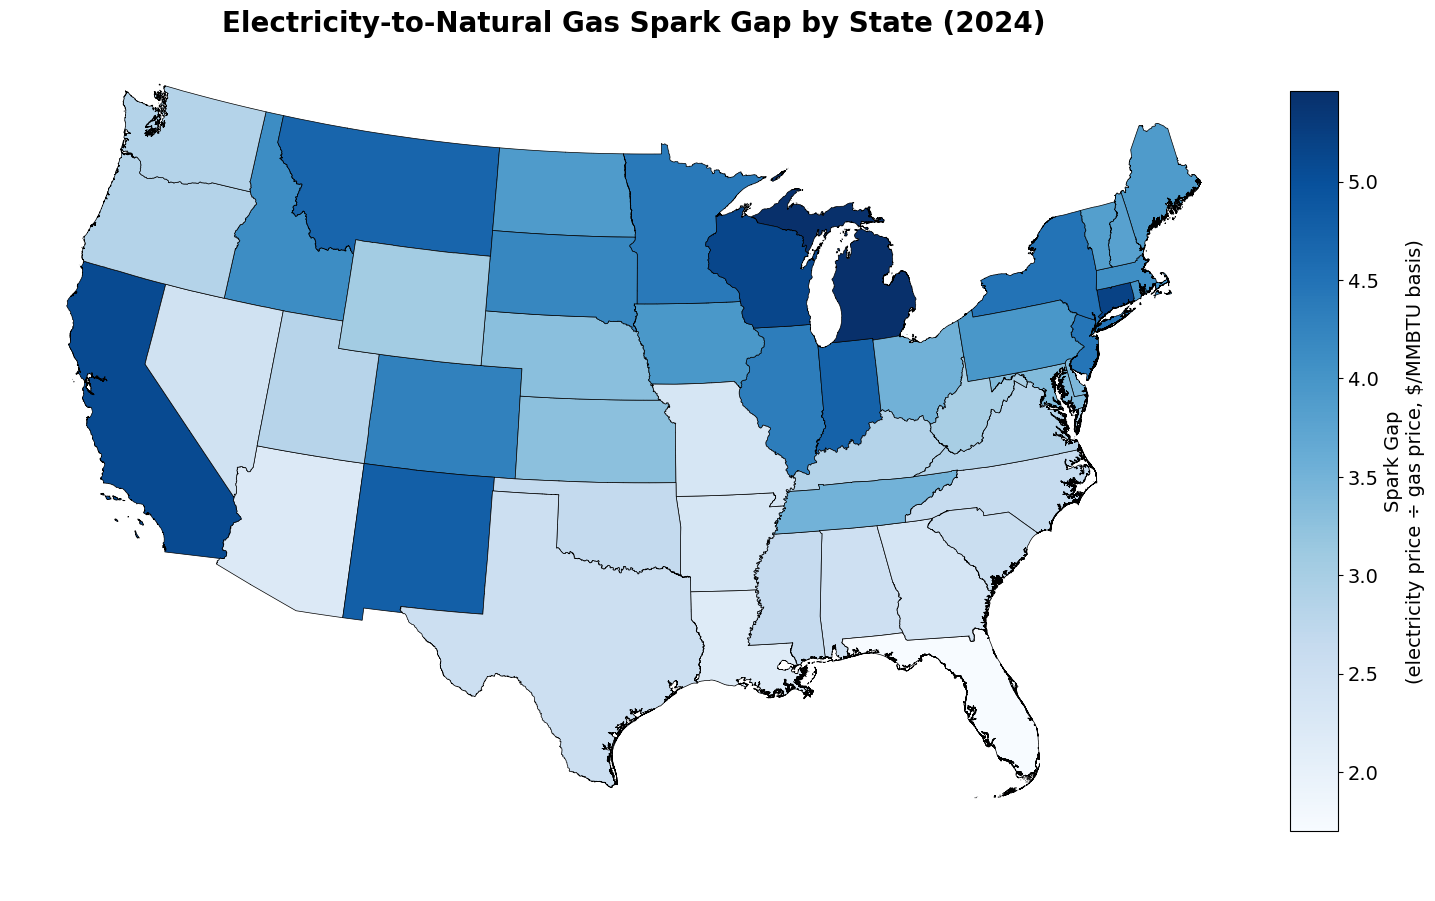

In [12]:
if gdf_conus is not None and gdf_alaska is not None:
    print("Generating choropleth maps...")

    # --- Spark gap (blue) ---
    create_choropleth_map(
        gdf_conus, gdf_alaska, column='spark_gap',
        title='Electricity-to-Natural Gas Spark Gap by State (2024)',
        cbar_label='Spark Gap\n(electricity price ÷ gas price, $/MMBTU basis)',
        output_path=os.path.join(PROJECT_ROOT, "state_spark_gap_map_2024.png"),
        cmap='Blues', show_plot=True,
    )

else:
    print("⚠ Maps skipped — no geodataframe available")

Generating choropleth maps...
  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_thermal_cop_mp3_mp4_map_2024.png


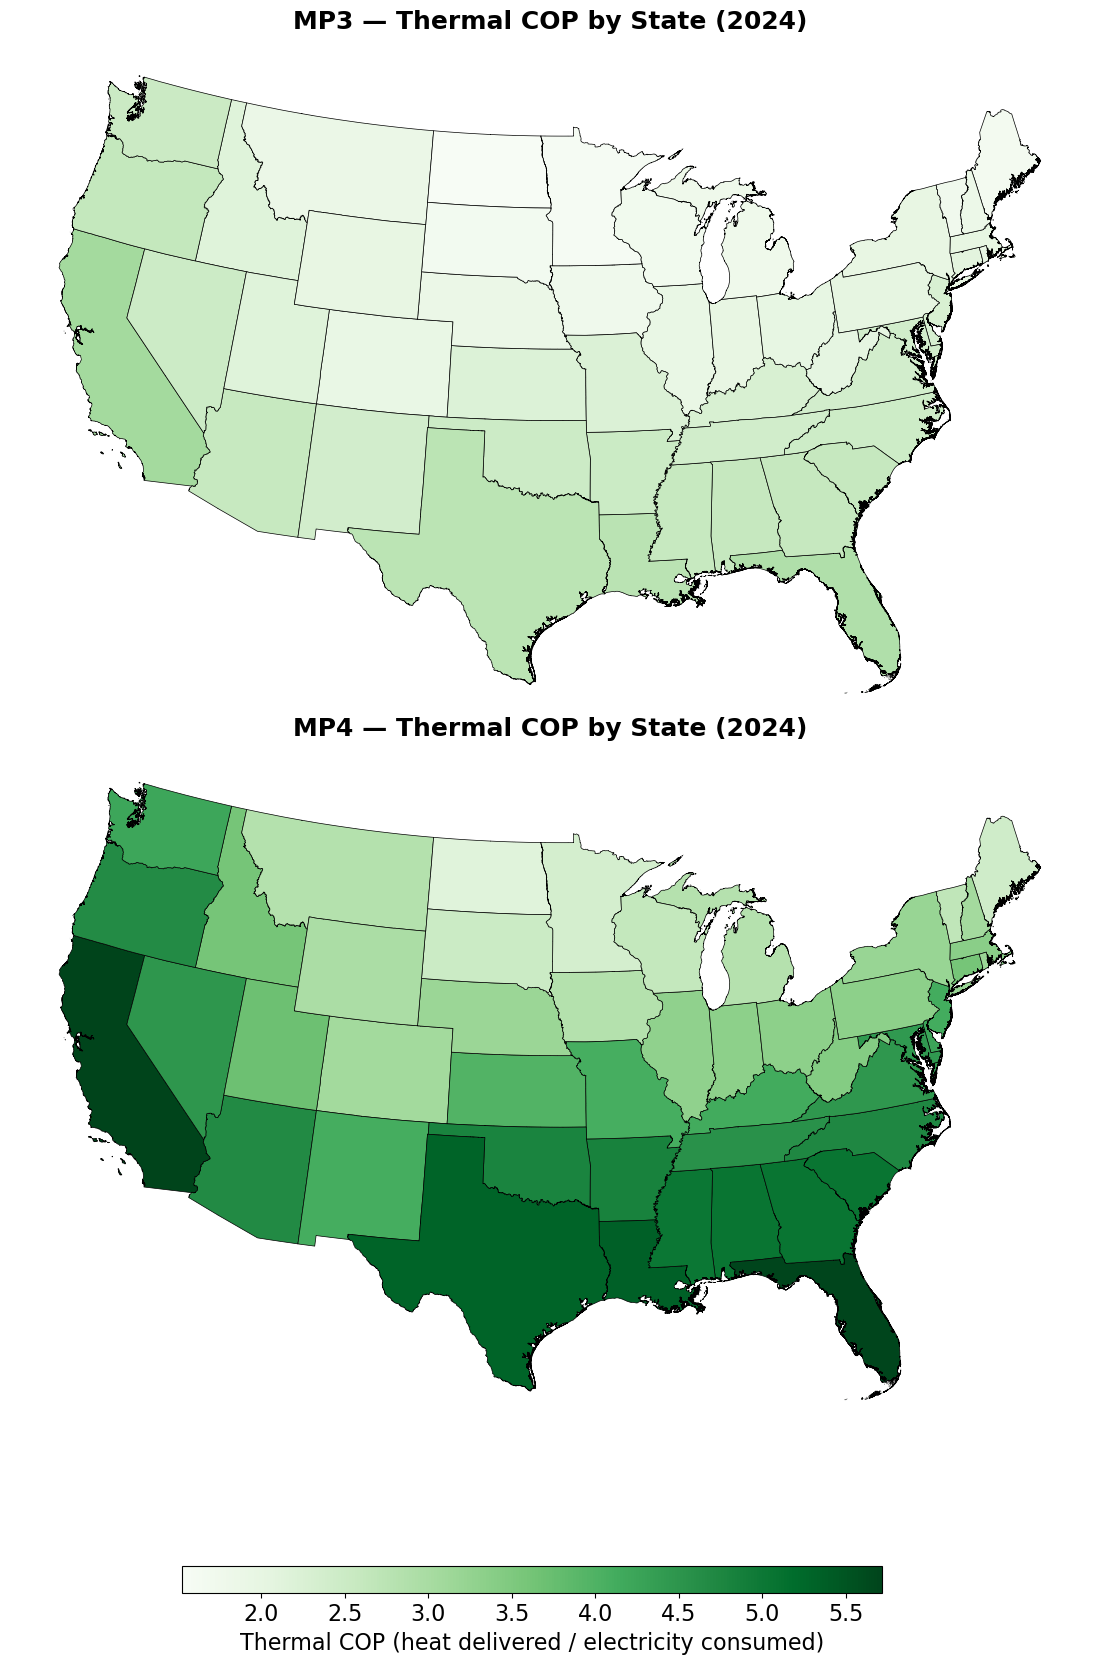

✓ Maps generated


In [13]:
if gdf_conus is not None and gdf_alaska is not None:
    print("Generating choropleth maps...")

    # --- Thermal COP: MP3 top / MP4 bottom with shared color scale (greens) ---
    cop_mps = [mp for mp in [3, 4] if mp in cop_results]
    if len(cop_mps) >= 2:
        # Build per-MP geodataframes and find shared color range
        gdf_cop_panels = {}
        all_vals = pd.Series(dtype=float)
        for mp_num in cop_mps:
            df_spark_mp = compute_spark_gap_metrics(df_prices_csv, cop_results[mp_num])
            _, gdf_c, gdf_a = prepare_state_geodataframe(
                gdf_states_raw, df_spark_mp, merge_col='state'
            )
            gdf_cop_panels[mp_num] = (gdf_c, gdf_a)
            all_vals = pd.concat([all_vals, gdf_c['thermal_cop'], gdf_a['thermal_cop']])

        shared_norm = mcolors.Normalize(vmin=all_vals.dropna().min(), vmax=all_vals.dropna().max())
        col = 'thermal_cop'
        nrows = len(cop_mps)

        fig, axes_grid = plt.subplots(nrows, 1, figsize=(14, 9 * nrows), facecolor='white')
        if nrows == 1:
            axes_grid = [axes_grid]

        for i, mp_num in enumerate(cop_mps):
            gdf_c, gdf_a = gdf_cop_panels[mp_num]
            ax = axes_grid[i]

            gdf_c.plot(ax=ax, column=col, cmap='Greens', edgecolor='black',
                       linewidth=0.5, norm=shared_norm, legend=False)
            ax.set_axis_off()
            ax.set_title(f'MP{mp_num} — Thermal COP by State (2024)',
                         fontsize=18, fontweight='bold', pad=12)

            # Alaska inset — only plot if data exists
            inset_bounds = ax.get_position()
            ax_ak = fig.add_axes([
                inset_bounds.x0, inset_bounds.y0,
                inset_bounds.width * 0.22, inset_bounds.height * 0.28,
            ])
            if not gdf_a.empty:
                gdf_a.plot(ax=ax_ak, column=col, cmap='Greens', edgecolor='black',
                           linewidth=0.5, norm=shared_norm, legend=False)
            ax_ak.set_axis_off()

        # Shared colorbar — bottom center
        cax = fig.add_axes([0.25, 0.02, 0.50, 0.015])
        sm = plt.cm.ScalarMappable(cmap='Greens', norm=shared_norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
        cbar.set_label('Thermal COP (heat delivered / electricity consumed)', fontsize=16)
        cax.tick_params(labelsize=16)

        fig.subplots_adjust(hspace=0.04)
        output = os.path.join(PROJECT_ROOT, "state_thermal_cop_mp3_mp4_map_2024.png")
        fig.savefig(output, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"  Saved: {output}")
        plt.show()
    elif len(cop_mps) == 1:
        create_choropleth_map(
            gdf_conus, gdf_alaska, column='thermal_cop',
            title=f'Heat Pump Thermal COP by State (MP{cop_mps[0]}, 2024)',
            cbar_label='Thermal COP\n(heat delivered / electricity consumed)',
            output_path=os.path.join(PROJECT_ROOT, f"state_thermal_cop_mp{cop_mps[0]}_map_2024.png"),
            cmap='Greens', show_plot=True,
        )
    else:
        print("⚠ No thermal COP results for MP3 or MP4 — skipping COP maps")

    print("✓ Maps generated")
else:
    print("⚠ Maps skipped — no geodataframe available")

Generating choropleth maps...
  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_breakeven_cop_90_map_2024.png


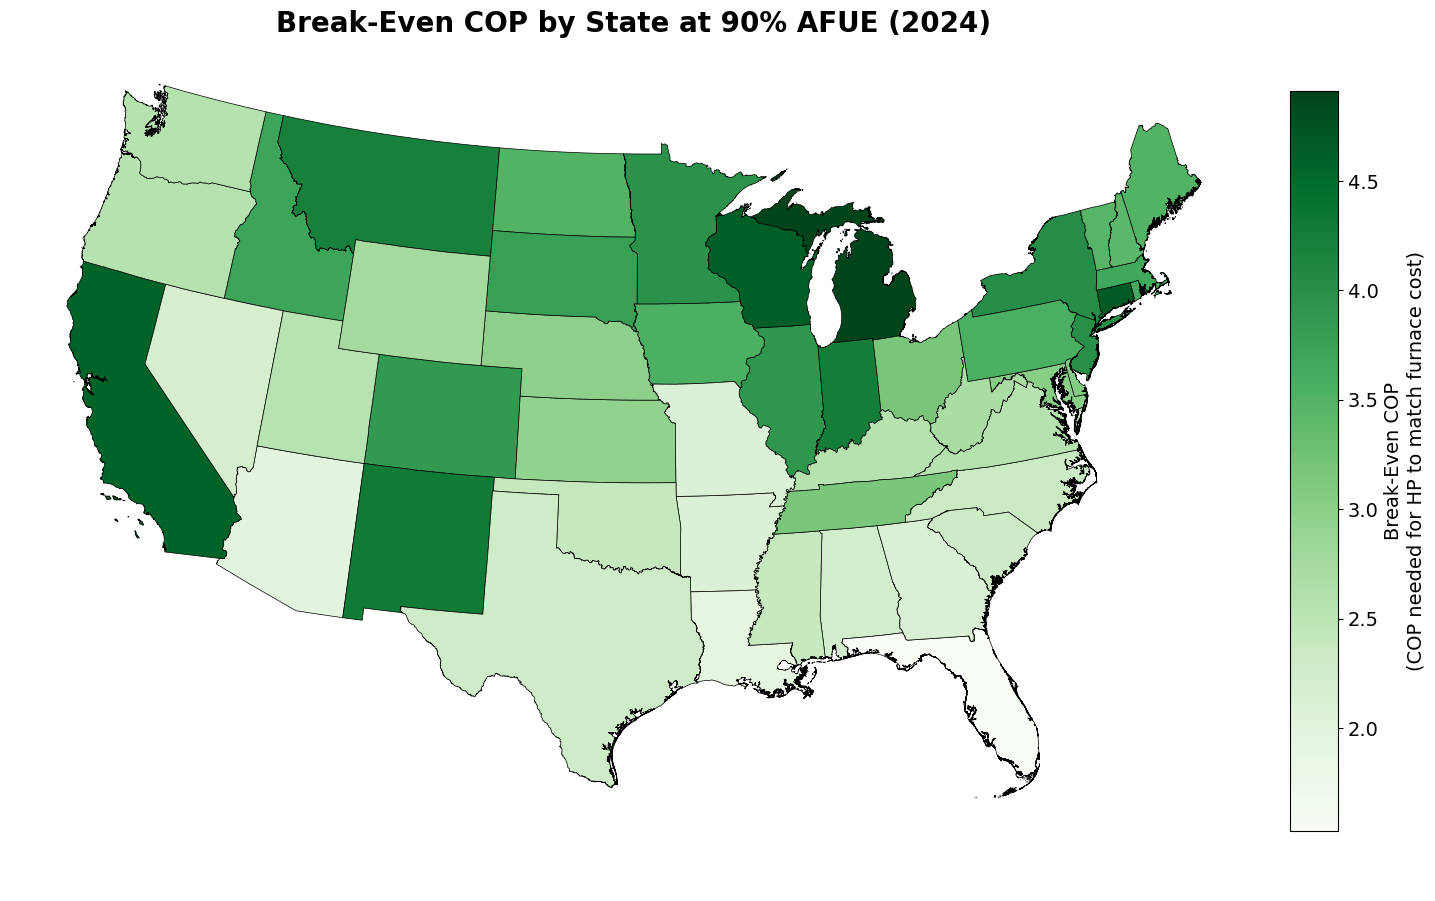

✓ Maps generated


In [14]:
from typing import Optional, Tuple
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def create_choropleth_map(
    gdf_conus: gpd.GeoDataFrame,
    gdf_alaska: gpd.GeoDataFrame,
    column: str,
    title: str,
    cbar_label: str,
    year: int = 2024,
    output_path:Optional[str] = None,
    figsize: Tuple[int, int] = (16, 10),
    dpi: int = 600,
    cmap: str = 'Blues',
    norm=None,
    show_plot: bool = True
) -> Optional[str]:
    """
    Create a choropleth map with CONUS main panel and Alaska inset.

    Pass a matplotlib Normalize (e.g. TwoSlopeNorm) via `norm` for diverging
    maps; otherwise linear normalization is derived from the data automatically.
    """
    plot_kw = dict(column=column, cmap=cmap, edgecolor='black', linewidth=0.5, legend=False)

    if norm is not None:
        plot_kw['norm'] = norm
    else:
        vals = pd.concat([gdf_conus[column], gdf_alaska[column]]).dropna()
        norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
        plot_kw['vmin'], plot_kw['vmax'] = vals.min(), vals.max()

    fig = plt.figure(figsize=figsize, facecolor='white')
    ax_main = fig.add_axes([0.02, 0.02, 0.78, 0.90])
    ax_ak = fig.add_axes([0.02, 0.02, 0.22, 0.25])

    gdf_conus.plot(ax=ax_main, **plot_kw)
    ax_main.set_axis_off()
    ax_main.set_title(title, fontsize=20, fontweight='bold', pad=12)

    if not gdf_alaska.empty:
        gdf_alaska.plot(ax=ax_ak, **plot_kw)
    ax_ak.set_axis_off()

    # Colorbar — matplotlib handles tick placement natively for any norm
    cax = fig.add_axes([0.82, 0.08, 0.03, 0.74])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, label=cbar_label).ax.yaxis.label.set_fontsize(14)
    cax.tick_params(labelsize=14)

    if output_path:
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"  Saved: {output_path}")
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    return output_path if output_path else None


if gdf_conus is not None and gdf_alaska is not None:
    print("Generating choropleth maps...")

    # --- Break-even COP at 90% AFUE (green) ---
    create_choropleth_map(
        gdf_conus, gdf_alaska, column='breakeven_cop_90',
        title='Break-Even COP by State at 90% AFUE (2024)',
        cbar_label='Break-Even COP\n(COP needed for HP to match furnace cost)',
        output_path=os.path.join(PROJECT_ROOT, "state_breakeven_cop_90_map_2024.png"),
        cmap='Greens', show_plot=True,
    )

    print("✓ Maps generated")
else:
    print("⚠ Maps skipped — no geodataframe available")

Generating break-even COP panel maps (80%, 90%, 95% AFUE)...
  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_breakeven_cop_80_90_95_panel_map_2024.png


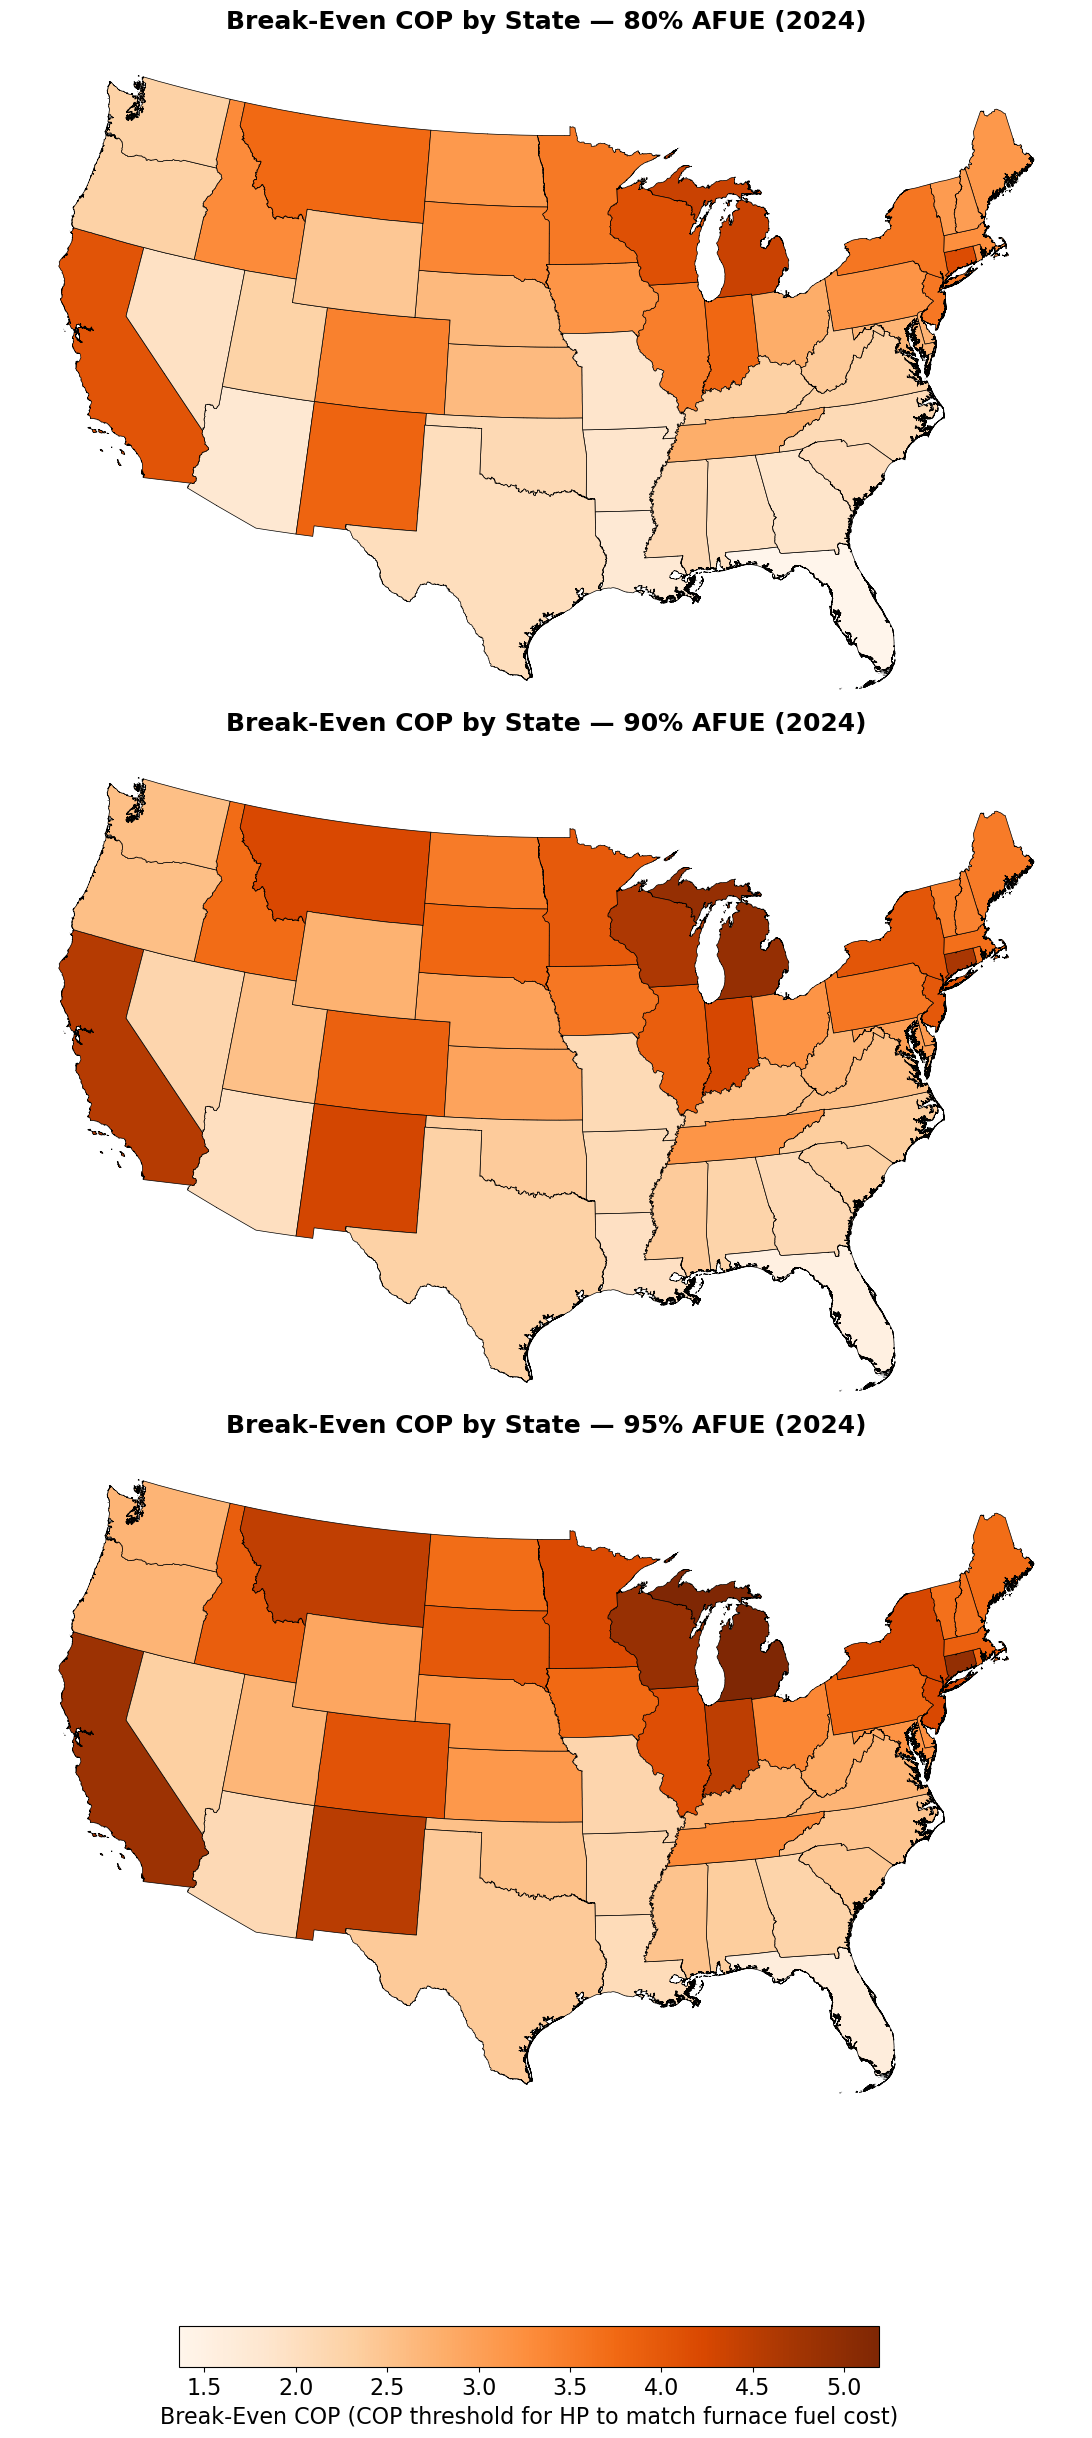

In [17]:
if gdf_conus is not None and gdf_alaska is not None:
    print("Generating break-even COP panel maps (80%, 90%, 95% AFUE)...")

    be_cols = ['breakeven_cop_80', 'breakeven_cop_90', 'breakeven_cop_95']
    be_labels = ['80% AFUE', '90% AFUE', '95% AFUE']

    # Shared color range across all three AFUE scenarios
    all_be_vals = pd.concat([
        pd.concat([gdf_conus[c], gdf_alaska[c]]) for c in be_cols
    ]).dropna()
    shared_norm = mcolors.Normalize(vmin=all_be_vals.min(), vmax=all_be_vals.max())

    nrows = len(be_cols)
    fig, axes_grid = plt.subplots(nrows, 1, figsize=(14, 9 * nrows), facecolor='white')

    for i, (col, label) in enumerate(zip(be_cols, be_labels)):
        ax = axes_grid[i]
        gdf_conus.plot(ax=ax, column=col, cmap='Oranges', edgecolor='black',
                       linewidth=0.5, norm=shared_norm, legend=False)
        ax.set_axis_off()
        ax.set_title(f'Break-Even COP by State — {label} (2024)',
                     fontsize=18, fontweight='bold', pad=12)

        # Alaska inset
        inset_bounds = ax.get_position()
        ax_ak = fig.add_axes([
            inset_bounds.x0, inset_bounds.y0,
            inset_bounds.width * 0.22, inset_bounds.height * 0.28,
        ])
        if not gdf_alaska.empty:
            gdf_alaska.plot(ax=ax_ak, column=col, cmap='Oranges', edgecolor='black',
                            linewidth=0.5, norm=shared_norm, legend=False)
        ax_ak.set_axis_off()

    # Shared colorbar — bottom center
    cax = fig.add_axes([0.25, 0.02, 0.50, 0.015])
    sm = plt.cm.ScalarMappable(cmap='Oranges', norm=shared_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('Break-Even COP (COP threshold for HP to match furnace fuel cost)', fontsize=16)
    cax.tick_params(labelsize=16)

    fig.subplots_adjust(hspace=0.04)
    output = os.path.join(PROJECT_ROOT, "state_breakeven_cop_80_90_95_panel_map_2024.png")
    fig.savefig(output, dpi=600, bbox_inches='tight', facecolor='white')
    print(f"  Saved: {output}")
    plt.show()
else:
    print("⚠ Maps skipped — no geodataframe available")

---
## Display Results
---

In [15]:
print("===== STATE PRICE RATIOS (2024 nominal) =====\n")
display(df_prices_csv)

for mp in selected_mps:
    print(f"\n===== THERMAL COP & AFUE (MP{mp}, NG homes) =====\n")
    display(cop_results[mp].sort_values('thermal_cop', ascending=False)[
        ['state', 'thermal_cop', 'baseline_afue', 'fans_pumps_pct', 'home_count']
    ])

# --- Comparison table: spark gap, break-even COP, effective COP ---
print(f"\n===== SPARK GAP & BREAK-EVEN COP vs EFFECTIVE COP (MP{primary_mp}) =====\n")

df_display = df_spark[[
    'state', 'state_name', 'spark_gap',
    'breakeven_cop_80', 'breakeven_cop_90', 'breakeven_cop_95', 'breakeven_cop_100',
    'thermal_cop', 'baseline_afue',
]].copy()

# Flag whether the heat pump beats the break-even threshold at 90% AFUE
df_display['hp_beats_breakeven_90'] = df_display['thermal_cop'] > df_display['breakeven_cop_90']

display(df_display.sort_values('spark_gap', ascending=False).reset_index(drop=True))

===== STATE PRICE RATIOS (2024 nominal) =====



,state,state_name,elec_price_kwh,gas_price_kwh,elec_price_mmbtu,gas_price_mmbtu,spark_gap
0,AK,Alaska,0.2482,0.0386,72.74,11.30,6.44
1,MI,Michigan,0.1930,0.0354,56.56,10.37,5.46
2,CT,Connecticut,0.2875,0.0553,84.26,16.21,5.20
3,WI,Wisconsin,0.1718,0.0333,50.35,9.77,5.15
4,CA,California,0.3197,0.0629,93.69,18.44,5.08
5,NM,New Mexico,0.1420,0.0297,41.62,8.72,4.77
6,IN,Indiana,0.1477,0.0312,43.29,9.15,4.73
7,MT,Montana,0.1266,0.0270,37.10,7.92,4.69
8,NY,New York,0.2443,0.0545,71.60,15.97,4.48
9,NJ,New Jersey,0.1934,0.0434,56.68,12.73,4.45



===== THERMAL COP & AFUE (MP3, NG homes) =====



,state,thermal_cop,baseline_afue,fans_pumps_pct,home_count
3,CA,3.054755,0.801801,4.001501,24571
8,FL,2.893052,0.794453,5.682569,1084
16,LA,2.758595,0.799742,5.761571,2139
41,TX,2.748806,0.804379,5.035227,12362
6,DC,2.715392,0.752035,4.055966,338
35,OR,2.618561,0.820170,3.725680,2183
0,AL,2.608147,0.805110,4.792433,1853
38,SC,2.603092,0.808995,4.670975,1580
9,GA,2.598895,0.812388,4.839350,5111
2,AZ,2.588321,0.823168,5.414082,2757



===== THERMAL COP & AFUE (MP4, NG homes) =====



,state,thermal_cop,baseline_afue,fans_pumps_pct,home_count
3,CA,5.719542,0.801801,5.075078,24571
8,FL,5.697018,0.794453,5.459375,1084
16,LA,5.345519,0.799742,5.496742,2139
41,TX,5.303021,0.804379,5.558138,12362
0,AL,5.058210,0.805110,5.564781,1853
9,GA,5.057374,0.812388,5.699106,5111
38,SC,5.056874,0.808995,5.632238,1580
23,MS,5.024481,0.810445,5.541313,1219
6,DC,4.980642,0.752035,4.335234,338
1,AR,4.830257,0.804689,5.518244,1582



===== SPARK GAP & BREAK-EVEN COP vs EFFECTIVE COP (MP3) =====



,state,state_name,spark_gap,breakeven_cop_80,breakeven_cop_90,breakeven_cop_95,breakeven_cop_100,thermal_cop,baseline_afue,hp_beats_breakeven_90
0,MI,Michigan,5.46,4.37,4.91,5.19,5.46,1.785815,0.809416,False
1,CT,Connecticut,5.20,4.16,4.68,4.94,5.20,2.085552,0.803036,False
2,WI,Wisconsin,5.15,4.12,4.64,4.89,5.15,1.699153,0.804310,False
3,CA,California,5.08,4.06,4.57,4.83,5.08,3.054755,0.801801,False
4,NM,New Mexico,4.77,3.82,4.29,4.53,4.77,2.384277,0.811805,False
5,IN,Indiana,4.73,3.78,4.26,4.49,4.73,1.971601,0.804715,False
6,MT,Montana,4.69,3.75,4.22,4.46,4.69,1.892323,0.809666,False
7,NY,New York,4.48,3.58,4.03,4.26,4.48,1.974215,0.793466,False
8,NJ,New Jersey,4.45,3.56,4.00,4.23,4.45,2.294246,0.795664,False
9,MN,Minnesota,4.41,3.53,3.97,4.19,4.41,1.589963,0.801746,False
